In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys

# Add parent directory to path to load config
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
import config

# Set plot style for professional looking charts
sns.set_theme(style="whitegrid")

# Load PROCESSED data (Never run EDA on raw dirty data)
df = pd.read_csv(config.PROCESSED_DATA_PATH)
print("Data loaded successfully. Shape:", df.shape)

Data loaded successfully. Shape: (7032, 23)


C:\Users\lenovo\AppData\Local\Temp\ipykernel_35520\2668750559.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='Churn', palette='Set2')


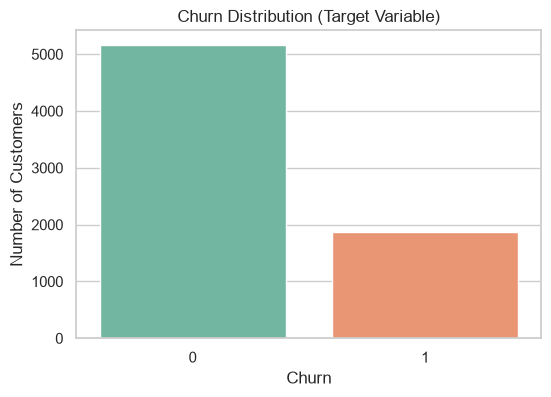

Global Churn Rate: 26.58%


In [4]:
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=df, x='Churn', palette='Set2')
plt.title("Churn Distribution (Target Variable)")
plt.ylabel("Number of Customers")
plt.show()

# Calculate percentages
churn_rate = df['Churn'].mean() * 100
print(f"Global Churn Rate: {churn_rate:.2f}%")

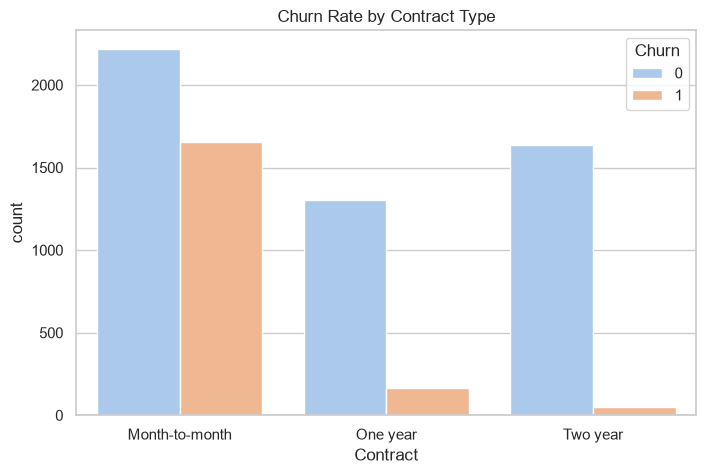

In [5]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Contract', hue='Churn', palette='pastel')
plt.title("Churn Rate by Contract Type")
plt.show()

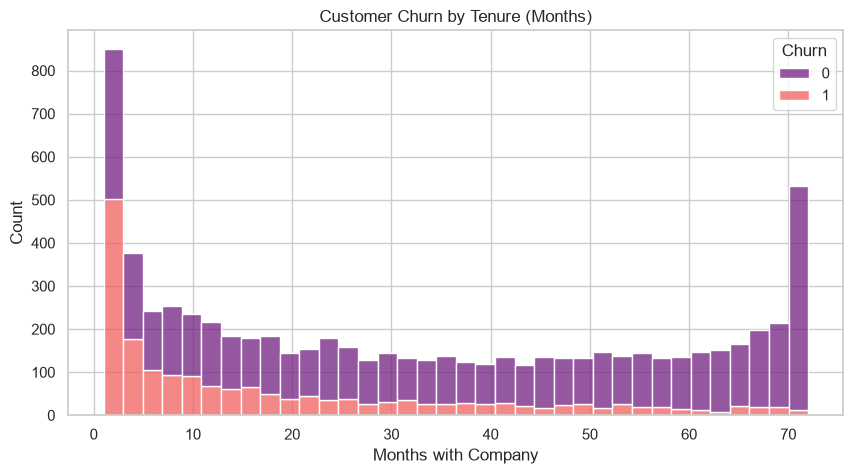

In [6]:
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='tenure', hue='Churn', multiple='stack', bins=36, palette='magma')
plt.title("Customer Churn by Tenure (Months)")
plt.xlabel("Months with Company")
plt.show()

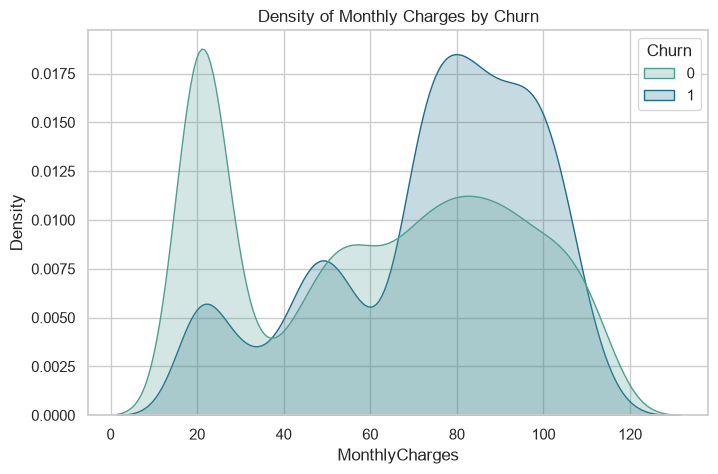

In [7]:
plt.figure(figsize=(8, 5))
sns.kdeplot(data=df, x='MonthlyCharges', hue='Churn', fill=True, common_norm=False, palette='crest')
plt.title("Density of Monthly Charges by Churn")
plt.show()

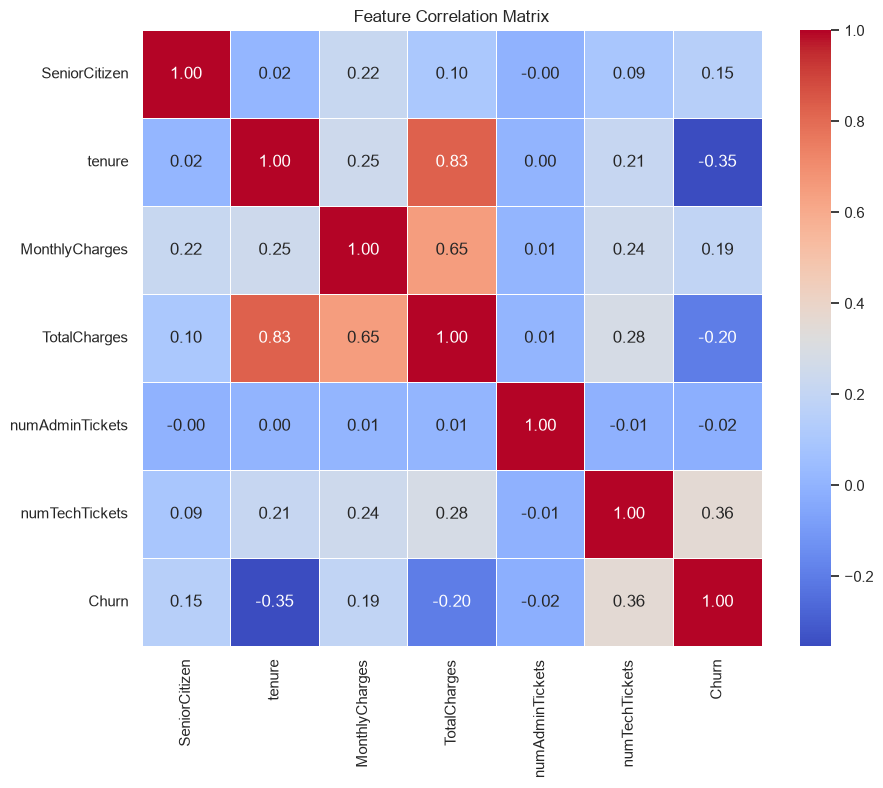

In [8]:
plt.figure(figsize=(10, 8))
# Filter only numerical columns for correlation
num_df = df.select_dtypes(include=['float64', 'int64'])
corr = num_df.corr()

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Feature Correlation Matrix")
plt.show()